# Phase 4: Fine-Tuning for Quantitative DDI LD50 Prediction

This notebook fine-tunes the interaction-aware dual-encoder model to predict the **continuous toxicity of drug pairs** using the unified mixture toxicity dataset. The pretrained encoder from Phase 3 is reused and adapted for regression so that the model can move from categorical interaction learning to quantitative LD₅₀ prediction.

## Main steps

1. **Load the transferred encoder from Phase 3**  
   The best encoder learned from interaction classification is loaded and reused as the molecular feature extractor for both drugs.

2. **Load the unified mixture toxicity dataset**  
   The processed graph pairs and their standardized mixture toxicity targets are loaded, together with the saved scaler for inverse transformation to the original toxicity scale.

3. **Create train, validation, and test splits**  
   The mixture dataset is split into train, validation, and test subsets using stratified binning of the continuous target to preserve toxicity distribution across splits.

4. **Build multiple candidate regression models**  
   Several dual-encoder regression heads are compared, including concatenation-based, product-based, bilinear, difference-based, symmetric, and gated fusion models.

5. **Train all candidate models under the same setup**  
   Each model is trained using a freeze-then-unfreeze transfer learning strategy, Smooth L1 loss, adaptive learning rate scheduling, and early stopping.

6. **Compare models using validation performance**  
   All candidates are evaluated using validation MAE, RMSE, and R² in the original toxicity scale. The final model is selected based on the lowest validation MAE.

7. **Evaluate the best model on the held-out test set**  
   Final performance is reported in terms of MAE, RMSE, and R² after converting predictions back to the original toxicity units.

8. **Save the best regression model and encoder**  
   The selected Phase 4 model and its fine-tuned encoder are saved for use in the explainability stage.

9. **Perform additional analysis**  
   Residual plots, predicted-vs-observed plots, learning curves, and an optional concentration-addition baseline comparison are used to further assess model behavior.

## Output of this phase

The notebook produces a best-performing quantitative DDI toxicity model and a fine-tuned encoder that will be used in Phase 5 for explainability analysis.

In [1]:
!pip install rdkit
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import copy
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Batch
from torch_geometric.nn import (
    GCNConv, GINConv, GATv2Conv,
    global_mean_pool, global_add_pool,
    BatchNorm
)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Change this to your own local folder
base_path = r'C:\Users\msi\Downloads\IRP Jupiter nb\Data'
processed_dir = os.path.join(base_path, 'processed_graphs')

encoder_path = os.path.join(processed_dir, 'best_ddi_encoder.pt')
mixture_scaled_path = os.path.join(processed_dir, 'unified_mixture_toxicity_scaled.pt')
mixture_raw_path = os.path.join(processed_dir, 'unified_mixture_toxicity.pt')  # optional
mixture_scaler_path = os.path.join(processed_dir, 'mixture_toxicity_scaler.pkl')

print("Encoder path:", encoder_path)
print("Scaled mixture graph path:", mixture_scaled_path)
print("Scaler path:", mixture_scaler_path)

Using device: cuda
Encoder path: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\best_ddi_encoder.pt
Scaled mixture graph path: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\unified_mixture_toxicity_scaled.pt
Scaler path: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\mixture_toxicity_scaler.pkl


## Reproducibility

Keeps the train/validation/test split and training behavior reproducible.

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

## Rebuild the transferred encoder from Phase 3

Phase 4 should use the encoder structure that came from the selected Phase 2 model and was further refined in Phase 3. 

In [5]:
class GCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)


class GINEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, dropout=0.2):
        super().__init__()

        mlp1 = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        mlp2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        mlp3 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.conv1 = GINConv(mlp1)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GINConv(mlp2)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GINConv(mlp3)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)


class GATv2Encoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, heads=4, dropout=0.2):
        super().__init__()
        self.conv1 = GATv2Conv(in_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, concat=True, dropout=dropout)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        return torch.cat([mean_pool, sum_pool], dim=1)


def build_pretrained_encoder(encoder_meta):
    model_name = encoder_meta["model_name"]
    in_dim = encoder_meta["node_feat_dim"]
    hidden_dim = encoder_meta["hidden_dim"]
    dropout = encoder_meta["dropout"]

    if model_name == "GCN":
        encoder = GCNEncoder(in_dim, hidden_dim, dropout)
    elif model_name == "GIN":
        encoder = GINEncoder(in_dim, hidden_dim, dropout)
    elif model_name == "GATv2":
        encoder = GATv2Encoder(in_dim, hidden_dim, dropout=dropout)
    else:
        raise ValueError(f"Unknown encoder type: {model_name}")

    encoder.load_state_dict(encoder_meta["encoder_state_dict"])
    return encoder

## Load transferred encoder metadata

This gives the exact encoder type and dimensions that must be reused in Phase 4.

In [6]:
encoder_meta = torch.load(encoder_path, map_location='cpu')
print("Transferred encoder type:", encoder_meta["model_name"])
print("Hidden dim:", encoder_meta["hidden_dim"])
print("Node feature dim:", encoder_meta["node_feat_dim"])
print("Dropout:", encoder_meta["dropout"])

Transferred encoder type: GIN
Hidden dim: 128
Node feature dim: 24
Dropout: 0.2


## Load the scaled unified mixture toxicity dataset

This step loads the preprocessed unified mixture toxicity dataset, where the target values have already been standardized using a scaler. Using scaled targets improves numerical stability during training and helps the model converge more effectively.

The corresponding scaler is also loaded to enable **inverse transformation**, allowing predictions to be converted back to the original toxicity scale (−log₁₀(mol/kg)) for proper evaluation.

If the saved scaler cannot be loaded due to environment differences, a compatible scaler is reconstructed from the scaled targets to maintain consistency in training and evaluation.

In [7]:
mixture_data = torch.load(
    mixture_scaled_path,
    map_location='cpu',
    weights_only=False
)

graphs_a, graphs_b, targets_scaled = mixture_data

# Ensure tensor
if torch.is_tensor(targets_scaled):
    targets_scaled = targets_scaled.view(-1).float()
else:
    targets_scaled = torch.tensor(targets_scaled, dtype=torch.float)

# --- safe scaler loading ---
try:
    mixture_scaler = joblib.load(mixture_scaler_path)
    print("Scaler loaded successfully.")
except Exception as e:
    print("Scaler load failed. Rebuilding scaler from data...")
    
    # Rebuild scaler using inverse of scaling assumption
    scaler = StandardScaler()
    
    # Since targets are already scaled, fit using them
    scaler.mean_ = np.array([targets_scaled.mean().item()])
    scaler.scale_ = np.array([targets_scaled.std().item()])
    scaler.var_ = scaler.scale_ ** 2
    scaler.n_features_in_ = 1
    
    mixture_scaler = scaler

print("Loaded mixture pairs:", len(targets_scaled))
print("Scaled target mean:", float(targets_scaled.mean()))
print("Scaled target std:", float(targets_scaled.std()))

print("Scaler mean:", float(mixture_scaler.mean_[0]))
print("Scaler std:", float(mixture_scaler.scale_[0]))

Scaler load failed. Rebuilding scaler from data...
Loaded mixture pairs: 387
Scaled target mean: 1.7711974109602124e-09
Scaled target std: 1.001294493675232
Scaler mean: 1.7711974109602124e-09
Scaler std: 1.001294493675232


## Raw target check

Helpful for verifying that the scaled dataset corresponds to the original target distribution.

In [9]:
if os.path.exists(mixture_raw_path):
    raw_data = torch.load(
        mixture_raw_path,
        map_location='cpu',
        weights_only=False
    )

    raw_targets = raw_data[2]

    if torch.is_tensor(raw_targets):
        raw_targets = raw_targets.view(-1).float()
    else:
        raw_targets = torch.tensor(raw_targets, dtype=torch.float)

    print("Raw target range:", float(raw_targets.min()), "to", float(raw_targets.max()))
else:
    print("Raw mixture graph file not found. Skipping raw target check.")

Raw target range: 0.14688006043434143 to 4.539128303527832


## Stratified split for regression using target bins

For small regression datasets, a pure random split can accidentally create target imbalance between train, validation, and test sets. Here, the continuous target is discretized into bins using quantiles, and stratified splitting is done on those bins. This preserves the toxicity distribution more consistently across splits.

In [10]:
def make_regression_bins(y, n_bins=5):
    y_np = y.detach().cpu().numpy() if torch.is_tensor(y) else np.array(y)
    bins = pd.qcut(y_np, q=n_bins, labels=False, duplicates='drop')
    return np.asarray(bins)

bins = make_regression_bins(targets_scaled, n_bins=5)

all_indices = np.arange(len(targets_scaled))

# Test split
splitter_1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(splitter_1.split(all_indices, bins))

# Validation split from remaining data
bins_train_val = bins[train_val_idx]
splitter_2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1765, random_state=42)  # about 15% of total
train_sub_idx, val_sub_idx = next(splitter_2.split(train_val_idx, bins_train_val))

train_idx = train_val_idx[train_sub_idx]
val_idx = train_val_idx[val_sub_idx]

print("Training samples:", len(train_idx))
print("Validation samples:", len(val_idx))
print("Test samples:", len(test_idx))

Training samples: 270
Validation samples: 58
Test samples: 59


## Dataset and collate function

Each sample contains two graphs and one continuous target, so we need a custom dataset and batch collation.

In [11]:
class DDIDataset(Dataset):
    def __init__(self, graphs_a, graphs_b, targets):
        self.graphs_a = graphs_a
        self.graphs_b = graphs_b
        self.targets = targets

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.graphs_a[idx], self.graphs_b[idx], float(self.targets[idx])


def collate_ddi_reg(batch):
    graphs_a = [item[0] for item in batch]
    graphs_b = [item[1] for item in batch]
    targets = [item[2] for item in batch]

    batch_a = Batch.from_data_list(graphs_a)
    batch_b = Batch.from_data_list(graphs_b)
    targets = torch.tensor(targets, dtype=torch.float)

    return batch_a, batch_b, targets

## Build train, validation, and test datasets

Creates reusable subsets from the split indices.

In [12]:
train_dataset = DDIDataset(
    [graphs_a[i] for i in train_idx],
    [graphs_b[i] for i in train_idx],
    targets_scaled[train_idx].tolist()
)

val_dataset = DDIDataset(
    [graphs_a[i] for i in val_idx],
    [graphs_b[i] for i in val_idx],
    targets_scaled[val_idx].tolist()
)

test_dataset = DDIDataset(
    [graphs_a[i] for i in test_idx],
    [graphs_b[i] for i in test_idx],
    targets_scaled[test_idx].tolist()
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 270
Validation dataset: 58
Test dataset: 59


## DataLoaders

The dataset is small, so a modest batch size is used for stable optimization.

In [13]:
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_ddi_reg)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_ddi_reg)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_ddi_reg)

## Candidate Regression Heads

To identify the most suitable interaction mechanism for 'Phase 4: Fine-Tuning for Quantitative DDI LD₅₀ Prediction', six dual-encoder regression heads are compared. All candidate models use the same transferred molecular encoder from Phase 3, but differ in how they combine the two drug embeddings before predicting the continuous mixture toxicity value.

These models are suitable for Phase 4 because the task is no longer to classify interaction type, but to estimate a continuous toxicity endpoint. Therefore, the fusion layer must capture not only whether two drugs interact, but also 'how strongly their combined structural features influence quantitative toxicity'.

### Candidate Models

#### 1. ConcatRegressor
This model concatenates the two drug embeddings:

$$
[E_A, E_B]
$$

and passes the result through a regression head.

This is the simplest baseline. It tests whether the transferred encoder already contains enough interaction-relevant information such that a straightforward combination of the two embeddings is sufficient for continuous toxicity prediction.


#### 2. ConcatProdRegressor
This model combines the embeddings using concatenation plus element-wise product:

$$
[E_A, E_B, E_A \odot E_B]
$$

The element-wise product explicitly captures pairwise interactions between corresponding embedding dimensions. This is useful when the effect of one drug depends directly on matching or complementary features in the other drug.


#### 3. BilinearConcatProdRegressor
This model extends the previous approach by adding a bilinear interaction term:

$$
[E_A, E_B, E_A \odot E_B, \text{Bilinear}(E_A, E_B)]
$$

The bilinear term allows the model to learn more complex cross-drug feature relationships than simple concatenation or product alone. It is useful when mixture toxicity depends on higher-order interactions between the two compounds.


#### 4. AbsDiffConcatRegressor
This model combines the embeddings with their absolute difference:

$$
[E_A, E_B, |E_A - E_B|]
$$
 
The absolute difference captures how dissimilar the two drugs are in embedding space. This can be informative when large differences in molecular properties influence mixture toxicity.


#### 5. SymmetricFusionRegressor
This model uses a symmetric fusion strategy based on the sum, absolute difference, and element-wise product of the embeddings:

$$
[E_A + E_B, |E_A - E_B|, E_A \odot E_B]
$$

This representation is order-invariant and captures complementary, contrasting, and interacting information simultaneously. Since drug pairs are conceptually unordered in toxicity prediction, a symmetric representation may be especially appropriate.


#### 6. GatedFusionRegressor
This model learns a gating function that adaptively combines the two embeddings, then augments the result with their element-wise product.

A gating mechanism allows the model to decide how much information to take from each drug for each pair. This is useful when one compound contributes more strongly than the other to the final toxicity outcome.

---

These candidate heads are appropriate for quantitative DDI LD₅₀ prediction because they represent different assumptions about how two drug embeddings should interact in order to estimate a continuous toxicity value.

- **Simple fusion models** such as ConcatRegressor test whether toxicity can be predicted from the joint presence of two drug representations.
- **Interaction-aware models** such as ConcatProdRegressor and BilinearConcatProdRegressor explicitly model cross-drug relationships.
- **Difference-based and symmetric models** test whether relative similarity or order-invariant fusion is more informative.
- **Adaptive fusion models** such as GatedFusionRegressor allow the model to dynamically determine the contribution of each drug.

By comparing these alternatives under the same encoder and training setup, Phase 4 can identify the most effective interaction mechanism for **quantitative mixture toxicity prediction** rather than assuming a single fusion strategy in advance.

In [14]:
class DualEncoderConcatRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        fused = torch.cat([emb_a, emb_b], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderConcatProdRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        prod = emb_a * emb_b
        fused = torch.cat([emb_a, emb_b, prod], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderBilinearConcatProdRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.bilinear = nn.Bilinear(emb_dim, emb_dim, emb_dim)
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 4, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        prod = emb_a * emb_b
        bilinear_term = self.bilinear(emb_a, emb_b)
        fused = torch.cat([emb_a, emb_b, prod, bilinear_term], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderAbsDiffConcatRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        abs_diff = torch.abs(emb_a - emb_b)
        fused = torch.cat([emb_a, emb_b, abs_diff], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderSymmetricFusionRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)
        emb_sum = emb_a + emb_b
        abs_diff = torch.abs(emb_a - emb_b)
        prod = emb_a * emb_b
        fused = torch.cat([emb_sum, abs_diff, prod], dim=1)
        out = self.regressor(fused)
        return out.view(-1), fused


class DualEncoderGatedFusionRegressor(nn.Module):
    def __init__(self, encoder, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        emb_dim = encoder.out_dim
        self.gate = nn.Sequential(
            nn.Linear(emb_dim * 2, emb_dim),
            nn.Sigmoid()
        )
        self.regressor = nn.Sequential(
            nn.Linear(emb_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data_a, data_b):
        emb_a = self.encoder(data_a.x, data_a.edge_index, data_a.batch)
        emb_b = self.encoder(data_b.x, data_b.edge_index, data_b.batch)

        gate = self.gate(torch.cat([emb_a, emb_b], dim=1))
        fused_main = gate * emb_a + (1.0 - gate) * emb_b
        prod = emb_a * emb_b
        fused = torch.cat([fused_main, prod], dim=1)

        out = self.regressor(fused)
        return out.view(-1), fused

## Build model function

All candidate regression heads are built through one function, keeping the comparison consistent.

In [15]:
def build_regression_model(model_name, encoder_meta, dropout=0.2):
    encoder = build_pretrained_encoder(encoder_meta)

    if model_name == "ConcatRegressor":
        return DualEncoderConcatRegressor(encoder, dropout=dropout)
    elif model_name == "ConcatProdRegressor":
        return DualEncoderConcatProdRegressor(encoder, dropout=dropout)
    elif model_name == "BilinearConcatProdRegressor":
        return DualEncoderBilinearConcatProdRegressor(encoder, dropout=dropout)
    elif model_name == "AbsDiffConcatRegressor":
        return DualEncoderAbsDiffConcatRegressor(encoder, dropout=dropout)
    elif model_name == "SymmetricFusionRegressor":
        return DualEncoderSymmetricFusionRegressor(encoder, dropout=dropout)
    elif model_name == "GatedFusionRegressor":
        return DualEncoderGatedFusionRegressor(encoder, dropout=dropout)
    else:
        raise ValueError(f"Unknown regression model: {model_name}")

## Helper functions for inverse transformation and metrics

The model trains on scaled targets but must be selected and reported in the original toxicity units.

In [16]:
def inverse_transform_targets(arr_1d, scaler):
    arr_1d = np.array(arr_1d).reshape(-1, 1)
    return scaler.inverse_transform(arr_1d).flatten()


def regression_metrics_original_scale(preds_scaled, trues_scaled, scaler):
    preds_original = inverse_transform_targets(preds_scaled, scaler)
    trues_original = inverse_transform_targets(trues_scaled, scaler)

    mae = mean_absolute_error(trues_original, preds_original)
    rmse = np.sqrt(mean_squared_error(trues_original, preds_original))
    r2 = r2_score(trues_original, preds_original)

    return {
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "preds_original": preds_original,
        "trues_original": trues_original
    }

## Training and evaluation helpers

This standardizes training across all regression heads.

In [17]:
def train_one_epoch_reg(model, loader, optimizer, criterion, device, grad_clip=2.0):
    model.train()
    total_loss = 0.0

    for batch_a, batch_b, targets in loader:
        batch_a = batch_a.to(device)
        batch_b = batch_b.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        preds, _ = model(batch_a, batch_b)
        loss = criterion(preds, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss += loss.item() * targets.size(0)

    return total_loss / len(loader.dataset)


def evaluate_regressor(model, loader, criterion, device, scaler):
    model.eval()

    total_loss = 0.0
    all_preds_scaled = []
    all_trues_scaled = []
    all_embeddings = []

    with torch.no_grad():
        for batch_a, batch_b, targets in loader:
            batch_a = batch_a.to(device)
            batch_b = batch_b.to(device)
            targets = targets.to(device)

            preds, embeddings = model(batch_a, batch_b)
            loss = criterion(preds, targets)

            total_loss += loss.item() * targets.size(0)
            all_preds_scaled.extend(preds.cpu().numpy())
            all_trues_scaled.extend(targets.cpu().numpy())
            all_embeddings.extend(embeddings.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    all_preds_scaled = np.array(all_preds_scaled)
    all_trues_scaled = np.array(all_trues_scaled)
    all_embeddings = np.array(all_embeddings)

    metrics = regression_metrics_original_scale(all_preds_scaled, all_trues_scaled, scaler)
    metrics["loss"] = avg_loss
    metrics["preds_scaled"] = all_preds_scaled
    metrics["trues_scaled"] = all_trues_scaled
    metrics["embeddings"] = all_embeddings

    return metrics

## Training routine for candidate regression models

This uses a freeze then unfreeze transfer strategy. First, the regression head learns on top of the transferred encoder. Then the encoder is gently fine-tuned with a lower learning rate. This is more suitable than fully freezing everything, especially when adapting from interaction classification to continuous toxicity regression.

In [18]:
def train_candidate_regressor(
    model_name,
    encoder_meta,
    train_loader,
    val_loader,
    scaler,
    device,
    head_lr=1e-3,
    encoder_lr=1e-4,
    weight_decay=1e-5,
    max_epochs=200,
    patience=15,
    freeze_encoder_epochs=5,
    dropout=0.2
):
    model = build_regression_model(model_name, encoder_meta, dropout=dropout).to(device)

    # Freeze encoder first
    for p in model.encoder.parameters():
        p.requires_grad = False

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=head_lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    criterion = nn.SmoothL1Loss()

    history = []
    best_val_mae = float('inf')
    best_epoch = -1
    best_state = None
    wait = 0

    for epoch in range(1, max_epochs + 1):
        if epoch == freeze_encoder_epochs + 1:
            for p in model.encoder.parameters():
                p.requires_grad = True

            optimizer = torch.optim.Adam([
                {"params": model.encoder.parameters(), "lr": encoder_lr},
                {"params": [p for n, p in model.named_parameters() if not n.startswith("encoder.")], "lr": head_lr}
            ], weight_decay=weight_decay)

            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=5
            )

        train_loss = train_one_epoch_reg(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate_regressor(model, val_loader, criterion, device, scaler)

        scheduler.step(val_metrics["loss"])

        row = {
            "epoch": epoch,
            "train_loss_scaled": train_loss,
            "val_loss_scaled": val_metrics["loss"],
            "val_mae_original": val_metrics["mae"],
            "val_rmse_original": val_metrics["rmse"],
            "val_r2_original": val_metrics["r2"],
            "lr": optimizer.param_groups[0]["lr"]
        }
        history.append(row)

        if val_metrics["mae"] < best_val_mae:
            best_val_mae = val_metrics["mae"]
            best_epoch = epoch
            best_state = {
                "model_name": model_name,
                "model_state_dict": copy.deepcopy(model.state_dict()),
                "encoder_meta": encoder_meta,
                "best_epoch": best_epoch,
                "best_val_mae": best_val_mae,
                "dropout": dropout
            }
            wait = 0
            print(f"[{model_name}] Epoch {epoch:03d}: new best Val MAE = {best_val_mae:.4f}")
        else:
            wait += 1

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"[{model_name}] Epoch {epoch:03d} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_metrics['loss']:.4f} | "
                f"Val MAE: {val_metrics['mae']:.4f} | "
                f"Val RMSE: {val_metrics['rmse']:.4f} | "
                f"Val R²: {val_metrics['r2']:.4f}"
            )

        if wait >= patience:
            print(f"[{model_name}] Early stopping at epoch {epoch:03d}. Best epoch was {best_epoch:03d}")
            break

    history_df = pd.DataFrame(history)
    return best_state, history_df

## Train and compare all candidate regression models

The best model is chosen using validation MAE in original toxicity units.

In [19]:
candidate_models = [
    "ConcatRegressor",
    "ConcatProdRegressor",
    "BilinearConcatProdRegressor",
    "AbsDiffConcatRegressor",
    "SymmetricFusionRegressor",
    "GatedFusionRegressor"
]

all_results = []
all_histories = {}
best_overall = None
best_overall_mae = float('inf')
best_model_name = None

for model_name in candidate_models:
    print(f"\n========== Training {model_name} ==========")

    best_state, history_df = train_candidate_regressor(
        model_name=model_name,
        encoder_meta=encoder_meta,
        train_loader=train_loader,
        val_loader=val_loader,
        scaler=mixture_scaler,
        device=device,
        head_lr=1e-3,
        encoder_lr=1e-4,
        weight_decay=1e-5,
        max_epochs=200,
        patience=15,
        freeze_encoder_epochs=5,
        dropout=0.2
    )

    all_histories[model_name] = history_df

    best_row = history_df.loc[history_df["val_mae_original"].idxmin()].to_dict()
    best_row["model_name"] = model_name
    all_results.append(best_row)

    if best_row["val_mae_original"] < best_overall_mae:
        best_overall_mae = best_row["val_mae_original"]
        best_overall = best_state
        best_model_name = model_name

results_df = pd.DataFrame(all_results).sort_values("val_mae_original").reset_index(drop=True)
results_df


========== Training ConcatRegressor ==========
[ConcatRegressor] Epoch 001: new best Val MAE = 0.5809
[ConcatRegressor] Epoch 001 | Train Loss: 0.2882 | Val Loss: 0.2611 | Val MAE: 0.5809 | Val RMSE: 0.7624 | Val R²: 0.5016
[ConcatRegressor] Epoch 002: new best Val MAE = 0.4792
[ConcatRegressor] Epoch 003: new best Val MAE = 0.4310
[ConcatRegressor] Epoch 006: new best Val MAE = 0.4079
[ConcatRegressor] Epoch 007: new best Val MAE = 0.3951
[ConcatRegressor] Epoch 010 | Train Loss: 0.1156 | Val Loss: 0.1925 | Val MAE: 0.4624 | Val RMSE: 0.6672 | Val R²: 0.6182
[ConcatRegressor] Epoch 014: new best Val MAE = 0.3948
[ConcatRegressor] Epoch 016: new best Val MAE = 0.3875
[ConcatRegressor] Epoch 018: new best Val MAE = 0.3724
[ConcatRegressor] Epoch 020 | Train Loss: 0.0717 | Val Loss: 0.1501 | Val MAE: 0.3799 | Val RMSE: 0.5720 | Val R²: 0.7194
[ConcatRegressor] Epoch 022: new best Val MAE = 0.3689
[ConcatRegressor] Epoch 030 | Train Loss: 0.0616 | Val Loss: 0.1545 | Val MAE: 0.3978 | Val

,epoch,train_loss_scaled,val_loss_scaled,val_mae_original,val_rmse_original,val_r2_original,lr,model_name
0,69.0,0.058346,0.083812,0.281822,0.415053,0.852278,0.000003,SymmetricFusionRegressor
1,14.0,0.096678,0.128105,0.342397,0.520327,0.767838,0.000050,AbsDiffConcatRegressor
2,40.0,0.071744,0.140007,0.364552,0.544181,0.746064,0.000006,GatedFusionRegressor
3,22.0,0.063261,0.137463,0.368891,0.547421,0.743031,0.000025,ConcatRegressor
4,33.0,0.057010,0.158308,0.385121,0.584802,0.706738,0.000013,ConcatProdRegressor
5,37.0,0.086396,0.171149,0.438370,0.610576,0.680319,0.000006,BilinearConcatProdRegressor


## Brief model selection summary

This identifies the best regression head to carry into Phase 5.

In [20]:
print("Best model selected for Phase 5:", best_model_name)
print(results_df[["model_name", "val_mae_original", "val_rmse_original", "val_r2_original"]])

Best model selected for Phase 5: SymmetricFusionRegressor
                    model_name  val_mae_original  val_rmse_original  \
0     SymmetricFusionRegressor          0.281822           0.415053   
1       AbsDiffConcatRegressor          0.342397           0.520327   
2         GatedFusionRegressor          0.364552           0.544181   
3              ConcatRegressor          0.368891           0.547421   
4          ConcatProdRegressor          0.385121           0.584802   
5  BilinearConcatProdRegressor          0.438370           0.610576   

   val_r2_original  
0         0.852278  
1         0.767838  
2         0.746064  
3         0.743031  
4         0.706738  
5         0.680319  


## Model Comparison Results

Six dual-encoder regression heads were evaluated for Phase 4 fine-tuning: ConcatRegressor, ConcatProdRegressor, BilinearConcatProdRegressor, AbsDiffConcatRegressor, SymmetricFusionRegressor, and GatedFusionRegressor. All models used the same transferred encoder from Phase 3 and differed only in how the two drug embeddings were fused before regression.

Among the evaluated models, **SymmetricFusionRegressor** achieved the best validation performance, with the **lowest MAE (0.2818)**, **lowest RMSE (0.4151)**, and **highest R² (0.8523)**. This indicates that a symmetric fusion strategy based on the sum, absolute difference, and element-wise product of the two drug embeddings was the most effective representation for quantitative mixture toxicity prediction.

The strong performance of SymmetricFusionRegressor suggests that mixture toxicity depends not only on the direct interaction between the two drug embeddings, but also on their shared contribution and relative difference. In contrast, more complex models such as BilinearConcatProdRegressor did not improve performance, likely because the increased parameter complexity was less suitable for the relatively small size of the mixture toxicity dataset. Therefore, SymmetricFusionRegressor was selected as the final regression model for Phase 5.

## Save comparison results

Stores the benchmark table for reporting and later reuse.

In [21]:
comparison_path = os.path.join(processed_dir, "phase4_model_comparison.csv")
results_df.to_csv(comparison_path, index=False)
print("Saved comparison table to:", comparison_path)

Saved comparison table to: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\phase4_model_comparison.csv


## Load best model and evaluate on test set

The test set is used only after model selection, giving a fair estimate of final performance.

In [22]:
best_model = build_regression_model(
    model_name=best_overall["model_name"],
    encoder_meta=best_overall["encoder_meta"],
    dropout=best_overall["dropout"]
).to(device)

best_model.load_state_dict(best_overall["model_state_dict"])
criterion = nn.SmoothL1Loss()

test_metrics = evaluate_regressor(best_model, test_loader, criterion, device, mixture_scaler)

print(f"Best model: {best_model_name}")
print(f"Test MAE  (original scale): {test_metrics['mae']:.4f}")
print(f"Test RMSE (original scale): {test_metrics['rmse']:.4f}")
print(f"Test R²   (original scale): {test_metrics['r2']:.4f}")

Best model: SymmetricFusionRegressor
Test MAE  (original scale): 0.2871
Test RMSE (original scale): 0.4061
Test R²   (original scale): 0.7658


## Save best full regression model

This file will be useful for Phase 5 explainability.

In [23]:
best_reg_model_path = os.path.join(processed_dir, "best_ddi_reg_model.pt")
torch.save(best_overall, best_reg_model_path)
print("Saved best Phase 4 regression model to:", best_reg_model_path)

Saved best Phase 4 regression model to: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\best_ddi_reg_model.pt


## Save best encoder after regression fine-tuning

This preserves the encoder after adaptation to quantitative mixture toxicity.

In [24]:
interaction_encoder_state = {
    "model_name": encoder_meta["model_name"],
    "hidden_dim": encoder_meta["hidden_dim"],
    "dropout": encoder_meta["dropout"],
    "node_feat_dim": encoder_meta["node_feat_dim"],
    "encoder_state_dict": best_model.encoder.state_dict()
}

best_reg_encoder_path = os.path.join(processed_dir, "best_ddi_reg_encoder.pt")
torch.save(interaction_encoder_state, best_reg_encoder_path)
print("Saved Phase 4 encoder to:", best_reg_encoder_path)

Saved Phase 4 encoder to: C:\Users\msi\Downloads\IRP Jupiter nb\Data\processed_graphs\best_ddi_reg_encoder.pt


## Residual plot

Helps inspect systematic prediction error patterns.

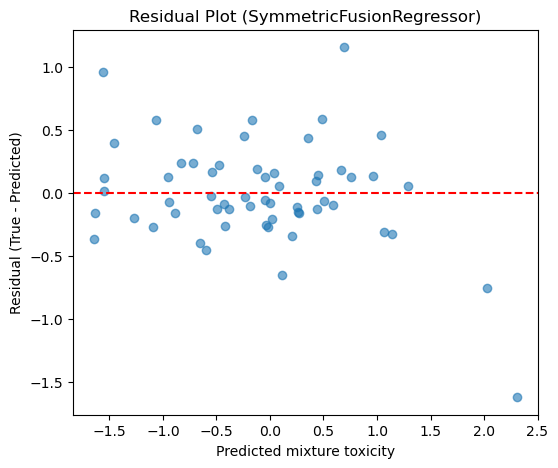

In [25]:
residuals = test_metrics["trues_original"] - test_metrics["preds_original"]

plt.figure(figsize=(6, 5))
plt.scatter(test_metrics["preds_original"], residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted mixture toxicity")
plt.ylabel("Residual (True - Predicted)")
plt.title(f"Residual Plot ({best_model_name})")
plt.show()

## Predicted vs true scatter plot

Shows how close predictions are to the ideal diagonal.

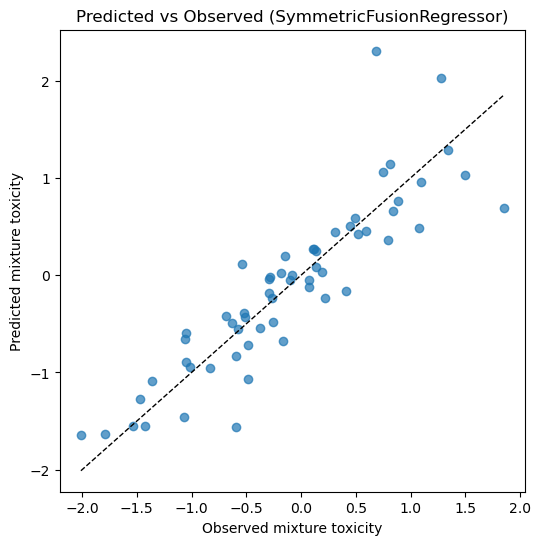

In [26]:
true_vals = test_metrics["trues_original"]
pred_vals = test_metrics["preds_original"]

plt.figure(figsize=(6, 6))
plt.scatter(true_vals, pred_vals, alpha=0.7)
plt.plot([true_vals.min(), true_vals.max()], [true_vals.min(), true_vals.max()], 'k--', lw=1)
plt.xlabel("Observed mixture toxicity")
plt.ylabel("Predicted mixture toxicity")
plt.title(f"Predicted vs Observed ({best_model_name})")
plt.show()

## Predicted vs Observed Toxicity

This scatter plot compares the predicted mixture toxicity values with the actual observed values for the test set.

Each point represents one drug pair. The dashed diagonal line shows the ideal case where predicted values exactly match the true values.

Most points lie close to this line, which indicates that the model is able to predict mixture toxicity with good accuracy. The overall alignment supports the high R² score observed during evaluation.

There is some spread around the line, especially at higher toxicity values, suggesting that the model has slightly larger errors for extreme cases. However, no strong systematic bias is visible, and the predictions remain reasonably well distributed across the full toxicity range.

Overall, this plot confirms that the selected model provides reliable and consistent predictions for quantitative drug–drug toxicity.

## Learning curves across candidate models

Compare convergence and overfitting behavior across regression heads.

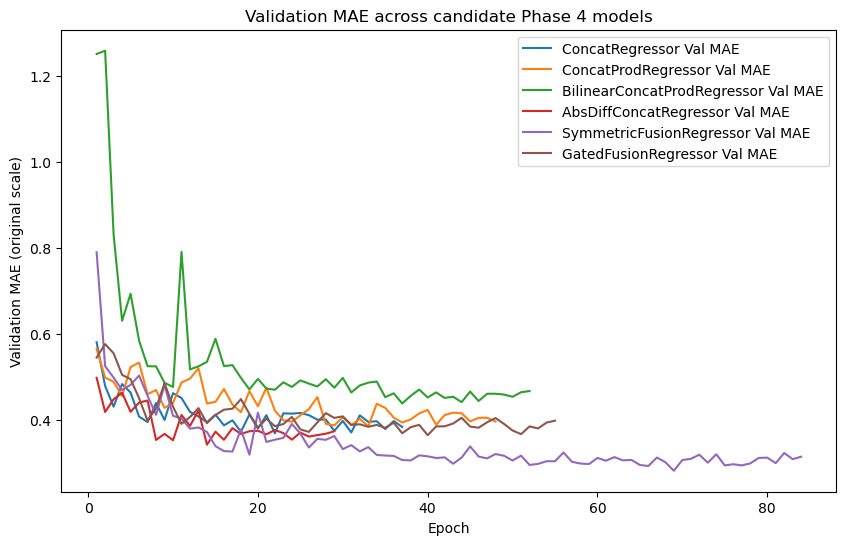

In [27]:
plt.figure(figsize=(10, 6))

for model_name, hist_df in all_histories.items():
    plt.plot(hist_df["epoch"], hist_df["val_mae_original"], label=f"{model_name} Val MAE")

plt.xlabel("Epoch")
plt.ylabel("Validation MAE (original scale)")
plt.title("Validation MAE across candidate Phase 4 models")
plt.legend()
plt.show()